In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# =========================
# CARGAR DATOS
# =========================

digits = load_digits()
X = digits.images
y = digits.target

# Normalizar
X = X / 16.0

# Dar formato CNN (samples, 8, 8, 1)
X = X.reshape(-1, 8, 8, 1)

# División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# MODELO CNN (MEJORADO)
# =========================

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(8,8,1)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # evita sobreajuste
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# ENTRENAMIENTO
# =========================

history = model.fit(
    X_train, y_train,
    epochs=25,
    validation_data=(X_test, y_test)
)

# =========================
# EVALUACIÓN
# =========================

loss, acc = model.evaluate(X_test, y_test)
print("Precisión final:", acc)


Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6033 - loss: 1.3951 - val_accuracy: 0.8778 - val_loss: 0.4607
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8608 - loss: 0.4616 - val_accuracy: 0.9417 - val_loss: 0.2099
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9165 - loss: 0.2849 - val_accuracy: 0.9583 - val_loss: 0.1512
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9339 - loss: 0.2071 - val_accuracy: 0.9778 - val_loss: 0.1018
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9527 - loss: 0.1658 - val_accuracy: 0.9750 - val_loss: 0.0940
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9624 - loss: 0.1308 - val_accuracy: 0.9806 - val_loss: 0.0859
Epoch 7/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9610 - loss: 0.1221 - val_accuracy: 0.9778 - val_loss: 0.0773
Epoch 8/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9666 - loss: 0.0971 - val_accuracy: 0.9694 - val_loss: 0.0678
Ep

### Visualización del Entrenamiento

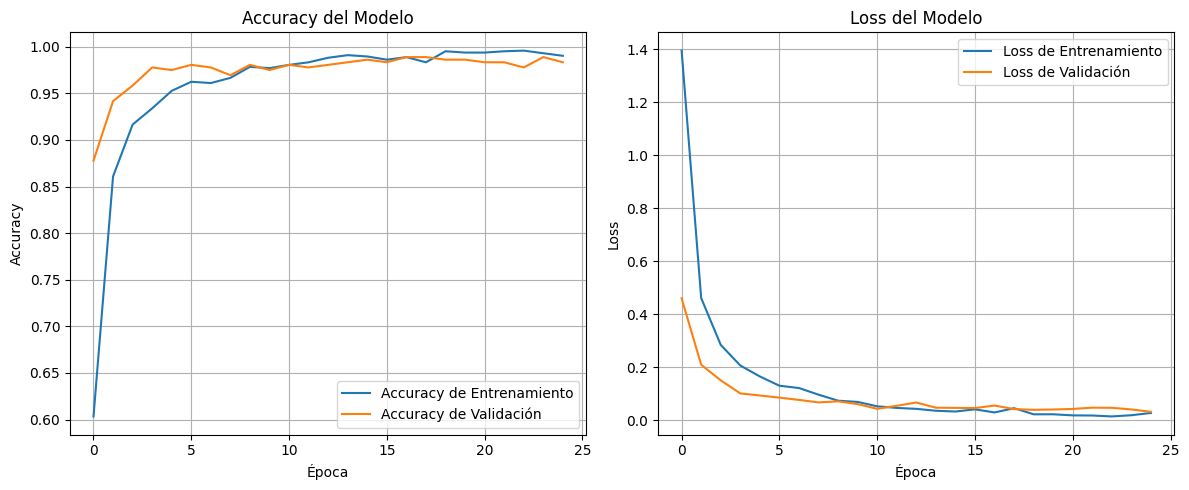

In [3]:
plt.figure(figsize=(12, 5))

# Gráfica de Accuracy
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history.history['accuracy'], label='Accuracy de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy de Validación')
plt.title('Accuracy del Modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Gráfica de Loss
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history.history['loss'], label='Loss de Entrenamiento')
plt.plot(history.history['val_loss'], label='Loss de Validación')
plt.title('Loss del Modelo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta el diseño para evitar superposiciones
plt.show()

In [4]:
from PIL import Image
import numpy as np

def preprocess_image_pro(image_file):
    img = Image.open(image_file).convert('L')

    # Redimensionar directo (sin recortar)
    img = img.resize((8, 8), Image.Resampling.LANCZOS)

    img = np.asarray(img)

    # 🔥 IMPORTANTE: invertir si fondo es blanco
    if np.mean(img) > 127:
        img = 255 - img

    # Normalizar igual que entrenamiento
    img = img / 255.0

    # Formato CNN
    img = img.reshape(1, 8, 8, 1)

    return img


Saving Captura de pantalla 2026-04-20 210759.png to Captura de pantalla 2026-04-20 210759.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


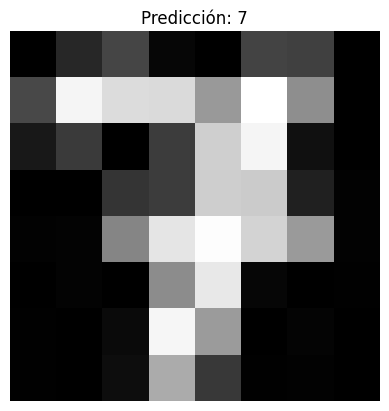

Probabilidades: [[1.5683744e-08 1.5674843e-05 9.1897000e-06 1.2112839e-04 3.0844938e-04
  4.7535515e-08 1.8966566e-10 9.9954528e-01 7.2405214e-08 1.0354135e-07]]
Resultado: 7


In [5]:
from google.colab import files
import io

def predict_image():
    uploaded = files.upload()

    for fn in uploaded.keys():
        img_file = io.BytesIO(uploaded[fn])

        processed = preprocess_image_pro(img_file)

        if processed is None:
            print("No se detectó número")
            return

        prediction = model.predict(processed)
        digit = np.argmax(prediction)

        plt.imshow(processed[0].reshape(8,8), cmap='gray')
        plt.title(f"Predicción: {digit}")
        plt.axis('off')
        plt.show()

        print("Probabilidades:", prediction)
        print("Resultado:", digit)

predict_image()
